# Chinese dynasties — individuals attached, floruit coverage, and temporal precision (Shang → Qing).

In [1]:
import random
import numpy as np
import polars as pl
import duckdb
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DB_PATH = '../../data/humans_clean.duckdb'

COLORS = {
    'all_individuals':   '#bcd1e3',
    'with_floruit':      '#2f5b8a',
    'precision_year':    '#1f3a5f',
    'precision_decade':  '#4c78a8',
    'precision_century': '#9bbcd9',
    'precision_dynasty': '#d8d2c3',
}

plt.rcParams.update({
    'figure.dpi':       120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    14,
    'axes.labelsize':    13,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'legend.fontsize':   11,
})


## Canonical Chinese dynasty list

In [2]:
CHINESE_DYNASTIES = [
    'Shang Dynasty',
    'Zhou Dynasty',
    'Qin Dynasty',
    'Han Dynasty',
    'Xin Dynasty',
    'Western Jin',
    'Eastern Jin',
    'Liu Song Dynasty',
    'Liang Dynasty',
    'Chen Dynasty',
    'Northern Wei',
    'Eastern Wei',
    'Western Wei',
    'Northern Zhou',
    'Northern Qi',
    'Sui Dynasty',
    'Tang Dynasty',
    'Five Dynasties and Ten Kingdoms',
    'Northern Song',
    'Southern Song',
    'Liao Dynasty',
    'Western Xia',
    'Yuan Dynasty',
    'Ming Dynasty',
    'Qing Dynasty',
]
print(f'dynasties: {len(CHINESE_DYNASTIES)}')


dynasties: 25


## Connect

In [3]:
con = duckdb.connect(DB_PATH, read_only=True)


## Dynasty periods

In [4]:
dynasty_periods = con.execute("""
    SELECT  polities_cliopatria.name AS dynasty,
            MIN(polities_periods_cliopatria.from_year) AS from_year,
            MAX(polities_periods_cliopatria.to_year)   AS to_year
    FROM        polities_cliopatria
    JOIN        polities_periods_cliopatria
            ON  polities_cliopatria.id = polities_periods_cliopatria.polity_id
    WHERE       polities_cliopatria.name = ANY(?)
    GROUP BY    polities_cliopatria.name
""", [CHINESE_DYNASTIES]).pl()

print('shape:', dynasty_periods.shape)
dynasty_periods.head()


shape: (24, 3)


dynasty,from_year,to_year
str,i64,i64
"""Eastern Wei""",534,554
"""Five Dynasties and Ten Kingdom…",911,979
"""Shang Dynasty""",-1600,-1001
"""Western Jin""",265,425
"""Chen Dynasty""",561,591


## Polity matches restricted to Chinese dynasties

In [5]:
dynasty_individuals = con.execute("""
    SELECT  individuals_cliopatria.wikidata_id,
            individuals_cliopatria.polity_name AS dynasty,
            individuals_floruit_period.method,
            individuals_floruit_period.floruit_period,
            individuals_floruit_period.floruit_period_start,
            individuals_floruit_period.floruit_period_end
    FROM       individuals_cliopatria
    LEFT JOIN  individuals_floruit_period USING (wikidata_id)
    WHERE      individuals_cliopatria.polity_name = ANY(?)
""", [CHINESE_DYNASTIES]).pl()

print('shape:', dynasty_individuals.shape)
dynasty_individuals.head()


shape: (85881, 6)


wikidata_id,dynasty,method,floruit_period,floruit_period_start,floruit_period_end
str,str,str,str,i64,i64
"""Q45455402""","""Tang Dynasty""","""birth_death_property""","""657-682""",657,682
"""Q45455406""","""Qing Dynasty""","""birth_only_property""","""1816-1841""",1816,1841
"""Q45455407""","""Qing Dynasty""","""birth_death_estimated_birth""","""1744-1769""",1744,1769
"""Q45455411""","""Tang Dynasty""","""birth_death_property""","""816-841""",816,841
"""Q45455418""","""Tang Dynasty""","""birth_death_estimated_birth""","""755-780""",755,780


## Counts per dynasty

In [6]:
dynasty_counts_raw = (
    dynasty_individuals
    .group_by('dynasty')
    .agg(
        pl.col('wikidata_id').n_unique().alias('all_individuals'),
        pl.col('wikidata_id')
          .filter(pl.col('floruit_period').is_not_null())
          .n_unique()
          .alias('with_floruit'),
    )
)

dynasty_summary = (
    pl.DataFrame({'dynasty': CHINESE_DYNASTIES})
    .join(dynasty_periods,     on='dynasty', how='left')
    .join(dynasty_counts_raw,  on='dynasty', how='left')
    .with_columns(
        pl.col('all_individuals').fill_null(0).cast(pl.Int64),
        pl.col('with_floruit').fill_null(0).cast(pl.Int64),
    )
    .with_columns(
        (pl.col('all_individuals') - pl.col('with_floruit')).alias('missing_floruit'),
        pl.when(pl.col('all_individuals') > 0)
          .then((100 * pl.col('with_floruit') / pl.col('all_individuals')).round(1))
          .otherwise(None)
          .alias('pct_with_floruit'),
    )
)

print('shape:', dynasty_summary.shape)
dynasty_summary


shape: (25, 7)


dynasty,from_year,to_year,all_individuals,with_floruit,missing_floruit,pct_with_floruit
str,i64,i64,i64,i64,i64,f64
"""Shang Dynasty""",-1600,-1001,7,7,0,100.0
"""Zhou Dynasty""",-1000,-751,11,11,0,100.0
"""Qin Dynasty""",-218,-209,26,26,0,100.0
"""Han Dynasty""",-202,237,1064,1064,0,100.0
"""Xin Dynasty""",6,29,30,30,0,100.0
…,…,…,…,…,…,…
"""Liao Dynasty""",911,1125,167,167,0,100.0
"""Western Xia""",990,1226,17,17,0,100.0
"""Yuan Dynasty""",1294,1374,2407,2407,0,100.0


In [ ]:
PRECISION_PRECEDENCE = {
    'birth_death_property':         'year',
    'birth_only_property':          'year',
    'birth_death_description':      'year',
    'birth_only_description':       'year',
    'birth_death_estimated_birth':  'year',
    'birth_death_cv':               'year',
    'birth_only_cv':                'year',
    'birth_death_wikipedia':        'year',
    'birth_only_wikipedia':         'year',
    'floruit_property':             'year',
    'floruit_description':          'year',
    'floruit_wikipedia':            'year',
    'floruit_wikipedia_span':       'year',
    'works_span':                   'year',
    'works_single':                 'year',
    'under_30':                     'year',
    'floruit_property_decade':      'decade',
    'birth_century':                'century',
    'birth_death_century':          'century',
    'death_century':                'century',
    'floruit_property_century':     'century',
    'no_data':                      'dynasty_only',
}

In [ ]:
PRECISION_COLUMNS = ['year', 'decade', 'century', 'dynasty_only']

precision_long = (
    dynasty_individuals
    .with_columns(
        pl.col('method')
          .fill_null('no_data')
          .replace_strict(PRECISION_PRECEDENCE, default='dynasty_only')
          .alias('precision')
    )
    .group_by(['dynasty', 'precision'])
    .agg(pl.col('wikidata_id').n_unique().alias('n'))
)

precision_counts = (
    precision_long
    .pivot(values='n', index='dynasty', on='precision', aggregate_function='sum')
)
for col in PRECISION_COLUMNS:
    if col not in precision_counts.columns:
        precision_counts = precision_counts.with_columns(pl.lit(0).cast(pl.Int64).alias(col))
precision_counts = (
    pl.DataFrame({'dynasty': CHINESE_DYNASTIES})
    .join(precision_counts, on='dynasty', how='left')
    .with_columns([pl.col(c).fill_null(0).cast(pl.Int64) for c in PRECISION_COLUMNS])
    .with_columns(
        sum(pl.col(c) for c in PRECISION_COLUMNS).alias('total')
    )
)

print('shape:', precision_counts.shape)
precision_counts

## Fig 2 — Temporal precision per dynasty

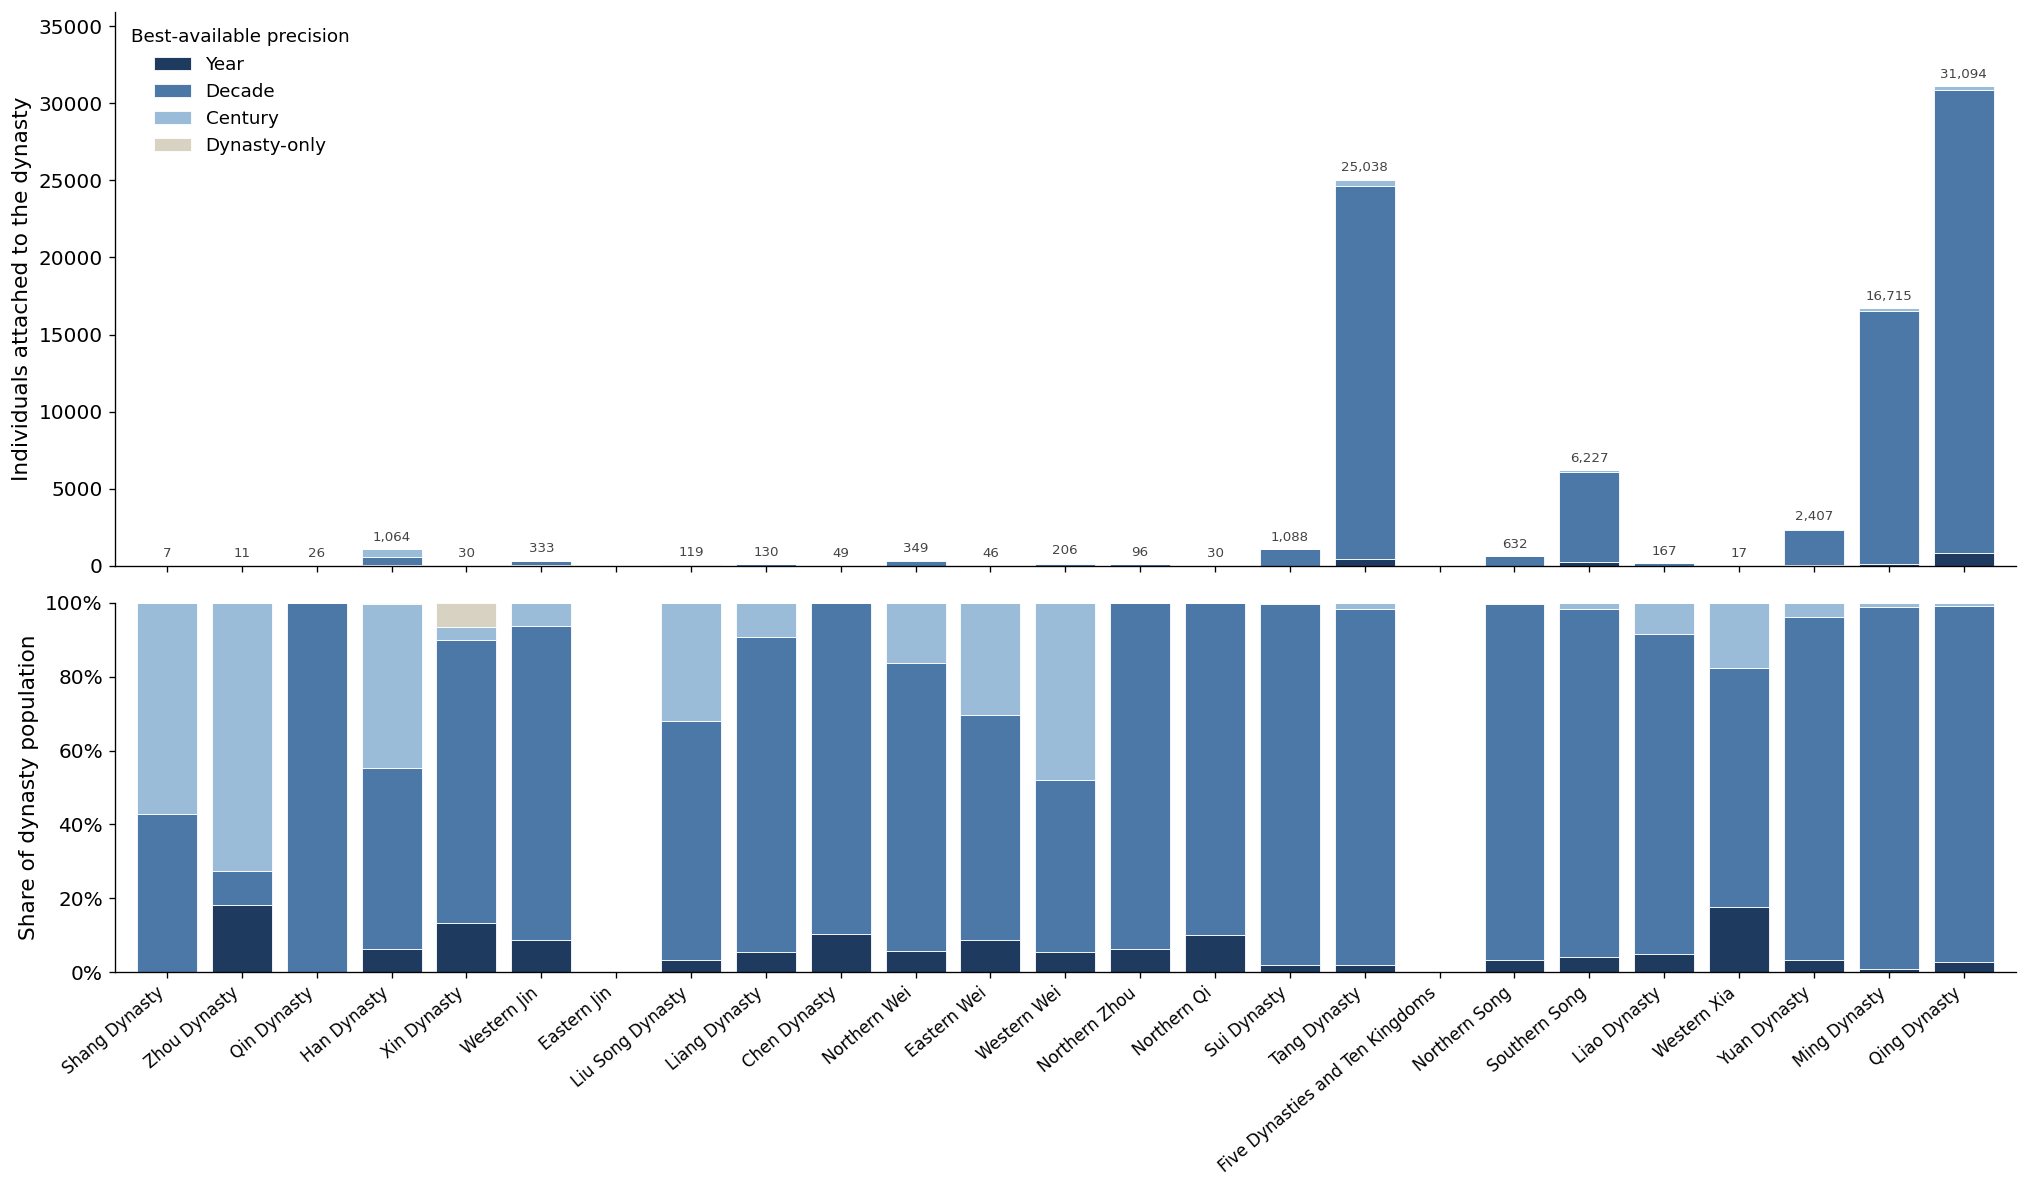

In [10]:
PRECISION_BUCKETS = [
    ('year',         'Year',         COLORS['precision_year']),
    ('decade',       'Decade',       COLORS['precision_decade']),
    ('century',      'Century',      COLORS['precision_century']),
    ('dynasty_only', 'Dynasty-only', COLORS['precision_dynasty']),
]

dynasty_axis = precision_counts['dynasty'].to_list()
totals       = precision_counts['total'].to_numpy().astype(float)
xs           = np.arange(len(dynasty_axis))

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(17, 10), sharex=True, gridspec_kw={'height_ratios': [3, 2]},
)

bottoms = np.zeros(len(dynasty_axis))
for column, label, color in PRECISION_BUCKETS:
    counts = precision_counts[column].to_numpy().astype(float)
    ax_top.bar(xs, counts, bottom=bottoms, color=color,
               edgecolor='white', linewidth=0.5, label=label)
    bottoms += counts

y_top = (totals.max() if totals.max() else 1.0) * 1.10
for i, total in enumerate(totals):
    if total > 0:
        ax_top.text(i, total + y_top * 0.01, f'{int(total):,}',
                    ha='center', va='bottom', fontsize=8, color='#444')
ax_top.set_ylim(0, y_top * 1.05)
ax_top.set_ylabel('Individuals attached to the dynasty')
ax_top.legend(frameon=False, loc='upper left',
              title='Best-available precision', title_fontsize=11)

shares = np.zeros((len(dynasty_axis), len(PRECISION_BUCKETS)))
for j, (column, _, _) in enumerate(PRECISION_BUCKETS):
    safe_totals = np.where(totals == 0, np.nan, totals)
    shares[:, j] = precision_counts[column].to_numpy() / safe_totals
shares = np.nan_to_num(shares)

bottoms = np.zeros(len(dynasty_axis))
for j, (_, _, color) in enumerate(PRECISION_BUCKETS):
    ax_bot.bar(xs, shares[:, j], bottom=bottoms, color=color,
               edgecolor='white', linewidth=0.5)
    bottoms += shares[:, j]
ax_bot.set_xticks(xs)
ax_bot.set_xticklabels(dynasty_axis, rotation=40, ha='right', fontsize=10)
ax_bot.set_xlim(-0.7, len(dynasty_axis) - 0.3)
ax_bot.set_ylim(0, 1.0)
ax_bot.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax_bot.set_ylabel('Share of dynasty population')

fig.tight_layout()
plt.show()


## Close

In [11]:
con.close()
